In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



Matplotlib is building the font cache; this may take a moment.


In [4]:
# === Fill these in ===
SEASON = "2024-2025"
LEAGUE = "Premier-League"

# If your odds are stored elsewhere, just update these:
BASE_ODDS_DIR = "../../data/raw/odds"  # e.g., s3 mounts, local path, etc.

OPENERS_PATH = f"{BASE_ODDS_DIR}/openers_{SEASON}_{LEAGUE}.parquet"
MIDWEEK_PATH = f"{BASE_ODDS_DIR}/midweek_{SEASON}_{LEAGUE}.parquet"
BET_PATH     = f"{BASE_ODDS_DIR}/bet_{SEASON}_{LEAGUE}.parquet"
CLOSE_PATH   = f"{BASE_ODDS_DIR}/close_{SEASON}_{LEAGUE}.parquet"

# Where to save the engineered panel:
OUT_PANEL = f"data/features/market_signals/odds_movement_panel_{SEASON}_{LEAGUE}.parquet"


In [2]:
SNAPSHOT_ORDER = ["openers", "midweek", "bet", "close"]

EXPECTED_COLS = [
    "event_id","sport_key","commence_time","home_team","away_team",
    "bookmaker","market","player","direction","line","price",
    "last_update","snapshot_type","snapshot_at","snapshot_written_at",
    "season","league_slug"
]

ID_KEYS = [
    "event_id","bookmaker","market","player","direction",
    "sport_key","season","league_slug","home_team","away_team","commence_time"
]

def robust_read(path: str) -> pd.DataFrame:
    """Try Parquet first, then CSV, then raw CSV."""
    p = Path(str(path).strip().strip("'").strip('"'))
    try:
        return pd.read_parquet(p)
    except Exception:
        if p.suffix.lower() != ".csv" and p.with_suffix(".csv").exists():
            return pd.read_csv(p.with_suffix(".csv"))
        return pd.read_csv(p)

def robust_write_parquet(df: pd.DataFrame, out_path: str) -> str:
    p = Path(out_path)
    p.parent.mkdir(parents=True, exist_ok=True)
    try:
        df.to_parquet(p, index=False)
        print(f"Saved Parquet → {p}")
        return str(p)
    except Exception:
        csv_path = p.with_suffix(".csv")
        df.to_csv(csv_path, index=False)
        print(f"[warn] Parquet failed; wrote CSV → {csv_path}")
        return str(csv_path)

def ensure_datetime(df: pd.DataFrame, cols) -> None:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")

def coerce_numeric(df: pd.DataFrame, cols) -> None:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

def implied_prob_from_decimal(odds: pd.Series) -> pd.Series:
    o = pd.to_numeric(odds, errors="coerce")
    return np.where(o > 0, 1.0 / o, np.nan)

def prep_snapshot(df: pd.DataFrame, snapshot_name: str) -> pd.DataFrame:
    # ensure required columns; tolerate missing ones for exploration
    missing = [c for c in EXPECTED_COLS if c not in df.columns]
    if missing:
        for c in missing:
            df[c] = np.nan

    out = df.copy()
    ensure_datetime(out, ["commence_time","last_update","snapshot_at","snapshot_written_at"])
    coerce_numeric(out, ["line","price"])
    out["prob"] = implied_prob_from_decimal(out["price"])
    out["snapshot"] = snapshot_name
    return out[EXPECTED_COLS + ["prob","snapshot"]]

def load_and_concat(openers_path, midweek_path, bet_path, close_path) -> pd.DataFrame:
    op  = prep_snapshot(robust_read(openers_path), "openers")
    mid = prep_snapshot(robust_read(midweek_path), "midweek")
    bet = prep_snapshot(robust_read(bet_path), "bet")
    clo = prep_snapshot(robust_read(close_path), "close")
    long = pd.concat([op, mid, bet, clo], ignore_index=True)
    long = long.sort_values(
        ["event_id","bookmaker","market","player","direction","snapshot","snapshot_at"],
        kind="mergesort"
    )
    return long

def to_wide(long: pd.DataFrame) -> pd.DataFrame:
    """
    One row per (event_id, bookmaker, market, player, direction).
    Columns: line_{snapshot}, price_{snapshot}, prob_{snapshot}
    """
    x = long[ID_KEYS + ["snapshot","line","price","prob"]].copy()
    wide_line  = x.pivot_table(index=ID_KEYS, columns="snapshot", values="line",  aggfunc="last")
    wide_price = x.pivot_table(index=ID_KEYS, columns="snapshot", values="price", aggfunc="last")
    wide_prob  = x.pivot_table(index=ID_KEYS, columns="snapshot", values="prob",  aggfunc="last")

    wide_line.columns  = [f"line_{c}"  for c in wide_line.columns]
    wide_price.columns = [f"price_{c}" for c in wide_price.columns]
    wide_prob.columns  = [f"prob_{c}"  for c in wide_prob.columns]

    wide = pd.concat([wide_line, wide_price, wide_prob], axis=1).reset_index()

    # reorder columns in canonical snapshot order
    def ordered(prefix):
        return [f"{prefix}_{s}" for s in SNAPSHOT_ORDER if f"{prefix}_{s}" in wide.columns]

    final_cols = ID_KEYS + ordered("line") + ordered("price") + ordered("prob")
    # include any leftovers
    final_cols += [c for c in wide.columns if c not in set(final_cols)]
    return wide[final_cols]

def add_movements(wide: pd.DataFrame) -> pd.DataFrame:
    out = wide.copy()

    def diff(end_col, start_col):
        a = pd.to_numeric(out.get(end_col), errors="coerce")
        b = pd.to_numeric(out.get(start_col), errors="coerce")
        return a - b

    # probability moves
    out["prob_move_open_close"] = diff("prob_close", "prob_openers")
    out["prob_move_mid_close"]  = diff("prob_close", "prob_midweek")
    out["prob_move_bet_close"]  = diff("prob_close", "prob_bet")
    out["abs_prob_move_open_close"] = out["prob_move_open_close"].abs()
    out["prob_move_sign_open_close"] = np.sign(out["prob_move_open_close"])

    # price moves (raw decimal odds; less linear)
    out["price_move_open_close"] = diff("price_close", "price_openers")
    out["price_move_mid_close"]  = diff("price_close", "price_midweek")
    out["price_move_bet_close"]  = diff("price_close", "price_bet")

    # line moves (totals/handicap); H2H often NaN
    out["line_move_open_close"] = diff("line_close", "line_openers")
    out["line_move_mid_close"]  = diff("line_close", "line_midweek")
    out["line_move_bet_close"]  = diff("line_close", "line_bet")

    # normalized move strength vs opening prob (optional)
    out["prob_move_strength"] = out["prob_move_open_close"] / (out["prob_openers"].abs() + 1e-9)
    return out

def summarize_by_event(wide_mv: pd.DataFrame) -> pd.DataFrame:
    keep = ID_KEYS + [
        "line_openers","line_close","line_move_open_close",
        "price_openers","price_close","price_move_open_close",
        "prob_openers","prob_close","prob_move_open_close","abs_prob_move_open_close"
    ]
    avail = [c for c in keep if c in wide_mv.columns]
    return wide_mv[avail].sort_values(["event_id","bookmaker","market","direction"])

def summarize_by_bookmaker(wide_mv: pd.DataFrame) -> pd.DataFrame:
    grp = wide_mv.groupby(["bookmaker","market"], dropna=False)["abs_prob_move_open_close"].mean()
    return grp.reset_index().rename(
        columns={"abs_prob_move_open_close":"avg_abs_prob_move_open_close"}
    ).sort_values("avg_abs_prob_move_open_close", ascending=False)

def summarize_by_market(wide_mv: pd.DataFrame) -> pd.DataFrame:
    grp = wide_mv.groupby(["market"], dropna=False)["line_move_open_close"].mean()
    return grp.reset_index().rename(
        columns={"line_move_open_close":"avg_line_move_open_close"}
    ).sort_values("avg_line_move_open_close", ascending=False)


In [5]:
openers = robust_read(OPENERS_PATH)
midweek  = robust_read(MIDWEEK_PATH)
bet      = robust_read(BET_PATH)
close    = robust_read(CLOSE_PATH)

print("Shapes:", openers.shape, midweek.shape, bet.shape, close.shape)

for name, df in [("openers", openers), ("midweek", midweek), ("bet", bet), ("close", close)]:
    print(f"\n=== {name} head ===")
    display(df.head(3))


/var/folders/l_/pcb32qsn4vz5n55rmw_4dctc0000gn/T/ipykernel_21173/4098396972.py:22: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(p.with_suffix(".csv"))


Shapes: (95450, 17) (164018, 17) (177494, 17) (177653, 17)

=== openers head ===


,event_id,sport_key,commence_time,home_team,away_team,bookmaker,market,player,direction,line,price,last_update,snapshot_type,snapshot_at,snapshot_written_at,season,league_slug
0,d7d17a7b0d52d798dd86ac09d6833189,soccer_epl,2024-11-03T14:00:00Z,Tottenham Hotspur,Aston Villa,onexbet,player_goal_scorer_anytime,John McGinn,Yes,1.0,6.00,2024-10-29T01:55:28Z,openers,2024-10-29T02:00:00Z,2025-09-13T18:23:59Z,2024-2025,Premier-League
1,d7d17a7b0d52d798dd86ac09d6833189,soccer_epl,2024-11-03T14:00:00Z,Tottenham Hotspur,Aston Villa,onexbet,player_goal_scorer_anytime,Tyrone Mings,Yes,1.0,15.00,2024-10-29T01:55:28Z,openers,2024-10-29T02:00:00Z,2025-09-13T18:23:59Z,2024-2025,Premier-League
2,d7d17a7b0d52d798dd86ac09d6833189,soccer_epl,2024-11-03T14:00:00Z,Tottenham Hotspur,Aston Villa,onexbet,player_goal_scorer_anytime,Timo Werner,Yes,1.0,3.25,2024-10-29T01:55:28Z,openers,2024-10-29T02:00:00Z,2025-09-13T18:23:59Z,2024-2025,Premier-League



=== midweek head ===


,event_id,sport_key,commence_time,home_team,away_team,bookmaker,market,player,direction,line,price,last_update,snapshot_type,snapshot_at,snapshot_written_at,season,league_slug
0,295b86b1f5f7bc00e459da5b998cba57,soccer_epl,2024-08-17T11:30:00Z,Ipswich Town,Liverpool,betonlineag,player_shots_on_target,Joe Gomez,Over,2.5,75.0,2024-08-14T23:25:01Z,midweek,2024-08-14T23:30:00Z,2025-10-07T23:45:27Z,2024-2025,Premier-League
1,295b86b1f5f7bc00e459da5b998cba57,soccer_epl,2024-08-17T11:30:00Z,Ipswich Town,Liverpool,betonlineag,player_shots_on_target,Joe Gomez,Over,1.5,30.0,2024-08-14T23:25:01Z,midweek,2024-08-14T23:30:00Z,2025-10-07T23:45:27Z,2024-2025,Premier-League
2,295b86b1f5f7bc00e459da5b998cba57,soccer_epl,2024-08-17T11:30:00Z,Ipswich Town,Liverpool,betonlineag,player_shots_on_target,Joe Gomez,Over,0.5,6.0,2024-08-14T23:25:01Z,midweek,2024-08-14T23:30:00Z,2025-10-07T23:45:27Z,2024-2025,Premier-League



=== bet head ===


,event_id,sport_key,commence_time,home_team,away_team,bookmaker,market,player,direction,line,price,last_update,snapshot_type,snapshot_at,snapshot_written_at,season,league_slug
0,7579d22151b7be3f590e9e338de9dff6,soccer_epl,2024-08-16T19:00:00Z,Manchester United,Fulham,betrivers,player_shots_on_target,Bruno Fernandes,Over,1.5,3.15,2024-08-15T18:54:58Z,bet,2024-08-15T19:00:00Z,2025-10-11T14:16:12Z,2024-2025,Premier-League
1,7579d22151b7be3f590e9e338de9dff6,soccer_epl,2024-08-16T19:00:00Z,Manchester United,Fulham,betrivers,player_shots_on_target,Rodrigo Muniz,Over,0.5,1.38,2024-08-15T18:54:58Z,bet,2024-08-15T19:00:00Z,2025-10-11T14:16:12Z,2024-2025,Premier-League
2,7579d22151b7be3f590e9e338de9dff6,soccer_epl,2024-08-16T19:00:00Z,Manchester United,Fulham,betrivers,player_shots_on_target,Harrison Reed,Over,0.5,3.80,2024-08-15T18:54:58Z,bet,2024-08-15T19:00:00Z,2025-10-11T14:16:12Z,2024-2025,Premier-League



=== close head ===


,event_id,sport_key,commence_time,home_team,away_team,bookmaker,market,player,direction,line,price,last_update,snapshot_type,snapshot_at,snapshot_written_at,season,league_slug
0,7579d22151b7be3f590e9e338de9dff6,soccer_epl,2024-08-16T19:00:00Z,Manchester United,Fulham,betrivers,player_shots_on_target,Bruno Fernandes,Over,1.5,3.15,2024-08-16T17:54:37Z,close,2024-08-16T18:00:00Z,2025-10-11T16:10:29Z,2024-2025,Premier-League
1,7579d22151b7be3f590e9e338de9dff6,soccer_epl,2024-08-16T19:00:00Z,Manchester United,Fulham,betrivers,player_shots_on_target,Rodrigo Muniz,Over,0.5,1.48,2024-08-16T17:54:37Z,close,2024-08-16T18:00:00Z,2025-10-11T16:10:29Z,2024-2025,Premier-League
2,7579d22151b7be3f590e9e338de9dff6,soccer_epl,2024-08-16T19:00:00Z,Manchester United,Fulham,betrivers,player_shots_on_target,Harrison Reed,Over,0.5,3.95,2024-08-16T17:54:37Z,close,2024-08-16T18:00:00Z,2025-10-11T16:10:29Z,2024-2025,Premier-League


In [6]:
long = load_and_concat(OPENERS_PATH, MIDWEEK_PATH, BET_PATH, CLOSE_PATH)
print("Long shape:", long.shape)
display(long.head(5))

print("\nValue counts — markets / bookmakers (long):")
display(long["market"].value_counts().head(20).to_frame("rows"))
display(long["bookmaker"].value_counts().head(20).to_frame("rows"))


/var/folders/l_/pcb32qsn4vz5n55rmw_4dctc0000gn/T/ipykernel_21173/4098396972.py:22: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(p.with_suffix(".csv"))


Long shape: (614615, 19)


,event_id,sport_key,commence_time,home_team,away_team,bookmaker,market,player,direction,line,price,last_update,snapshot_type,snapshot_at,snapshot_written_at,season,league_slug,prob,snapshot
291499,00351878709543ad15bbba4b7a2062a1,soccer_epl,2024-10-20 15:30:00+00:00,Liverpool,Chelsea,betclic,h2h,NaN,Chelsea,NaN,4.92,2024-10-19 15:24:52+00:00,bet,2024-10-19 15:30:00+00:00,2025-10-11 14:18:30+00:00,2024-2025,Premier-League,0.203252,bet
469367,00351878709543ad15bbba4b7a2062a1,soccer_epl,2024-10-20 15:30:00+00:00,Liverpool,Chelsea,betclic,h2h,NaN,Chelsea,NaN,4.45,2024-10-20 14:25:10+00:00,close,2024-10-20 14:30:00+00:00,2025-10-11 16:12:48+00:00,2024-2025,Premier-League,0.224719,close
119949,00351878709543ad15bbba4b7a2062a1,soccer_epl,2024-10-20 15:30:00+00:00,Liverpool,Chelsea,betclic,h2h,NaN,Chelsea,NaN,4.60,2024-10-18 03:24:58+00:00,midweek,2024-10-18 03:30:00+00:00,2025-10-07 23:47:45+00:00,2024-2025,Premier-League,0.217391,midweek
17599,00351878709543ad15bbba4b7a2062a1,soccer_epl,2024-10-20 15:30:00+00:00,Liverpool,Chelsea,betclic,h2h,NaN,Chelsea,NaN,4.37,2024-10-15 03:24:44+00:00,openers,2024-10-15 03:30:00+00:00,2025-10-11 13:41:51+00:00,2024-2025,Premier-League,0.228833,openers
291501,00351878709543ad15bbba4b7a2062a1,soccer_epl,2024-10-20 15:30:00+00:00,Liverpool,Chelsea,betclic,h2h,NaN,Draw,NaN,4.50,2024-10-19 15:24:52+00:00,bet,2024-10-19 15:30:00+00:00,2025-10-11 14:18:30+00:00,2024-2025,Premier-League,0.222222,bet



Value counts — markets / bookmakers (long):


,rows
market,
player_goal_scorer_anytime,209301
h2h,185093
player_shots_on_target,118247
totals,58814
spreads,26150
h2h_lay,17010


,rows
bookmaker,
fanduel,117460
betrivers,66742
onexbet,55386
bovada,54882
draftkings,45101
betmgm,26458
betonlineag,13999
matchbook,13966
pinnacle,10647


In [7]:
wide = to_wide(long)
print("Wide shape:", wide.shape)
display(wide.head(5))


Wide shape: (89687, 23)


,event_id,bookmaker,market,player,direction,sport_key,season,league_slug,home_team,away_team,...,line_bet,line_close,price_openers,price_midweek,price_bet,price_close,prob_openers,prob_midweek,prob_bet,prob_close
0,00351878709543ad15bbba4b7a2062a1,betmgm,player_goal_scorer_anytime,Alexis Mac Allister,Yes,soccer_epl,2024-2025,Premier-League,Liverpool,Chelsea,...,1.0,1.0,6.0,6.0,6.0,6.0,0.166667,0.166667,0.166667,0.166667
1,00351878709543ad15bbba4b7a2062a1,betmgm,player_goal_scorer_anytime,Andy Robertson,Yes,soccer_epl,2024-2025,Premier-League,Liverpool,Chelsea,...,1.0,1.0,12.0,12.0,12.0,12.0,0.083333,0.083333,0.083333,0.083333
2,00351878709543ad15bbba4b7a2062a1,betmgm,player_goal_scorer_anytime,Axel Disasi,Yes,soccer_epl,2024-2025,Premier-League,Liverpool,Chelsea,...,1.0,1.0,23.0,23.0,26.0,23.0,0.043478,0.043478,0.038462,0.043478
3,00351878709543ad15bbba4b7a2062a1,betmgm,player_goal_scorer_anytime,Ben Chilwell,Yes,soccer_epl,2024-2025,Premier-League,Liverpool,Chelsea,...,1.0,1.0,15.5,15.5,16.0,15.0,0.064516,0.064516,0.062500,0.066667
4,00351878709543ad15bbba4b7a2062a1,betmgm,player_goal_scorer_anytime,Benoît Badiashile,Yes,soccer_epl,2024-2025,Premier-League,Liverpool,Chelsea,...,1.0,1.0,23.0,23.0,26.0,23.0,0.043478,0.043478,0.038462,0.043478


In [8]:
wide_mv = add_movements(wide)
print("With movements shape:", wide_mv.shape)
display(wide_mv.head(5))


With movements shape: (89687, 35)


,event_id,bookmaker,market,player,direction,sport_key,season,league_slug,home_team,away_team,...,prob_move_bet_close,abs_prob_move_open_close,prob_move_sign_open_close,price_move_open_close,price_move_mid_close,price_move_bet_close,line_move_open_close,line_move_mid_close,line_move_bet_close,prob_move_strength
0,00351878709543ad15bbba4b7a2062a1,betmgm,player_goal_scorer_anytime,Alexis Mac Allister,Yes,soccer_epl,2024-2025,Premier-League,Liverpool,Chelsea,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,00351878709543ad15bbba4b7a2062a1,betmgm,player_goal_scorer_anytime,Andy Robertson,Yes,soccer_epl,2024-2025,Premier-League,Liverpool,Chelsea,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,00351878709543ad15bbba4b7a2062a1,betmgm,player_goal_scorer_anytime,Axel Disasi,Yes,soccer_epl,2024-2025,Premier-League,Liverpool,Chelsea,...,0.005017,0.000000,0.0,0.0,0.0,-3.0,0.0,0.0,0.0,0.000000
3,00351878709543ad15bbba4b7a2062a1,betmgm,player_goal_scorer_anytime,Ben Chilwell,Yes,soccer_epl,2024-2025,Premier-League,Liverpool,Chelsea,...,0.004167,0.002151,1.0,-0.5,-0.5,-1.0,0.0,0.0,0.0,0.033333
4,00351878709543ad15bbba4b7a2062a1,betmgm,player_goal_scorer_anytime,Benoît Badiashile,Yes,soccer_epl,2024-2025,Premier-League,Liverpool,Chelsea,...,0.005017,0.000000,0.0,0.0,0.0,-3.0,0.0,0.0,0.0,0.000000


In [15]:
print("Per-event (open→close):")
display(summarize_by_event(wide_mv[wide_mv['bookmaker'] == 'fanduel']).head(20))


Per-event (open→close):


,event_id,bookmaker,market,player,direction,sport_key,season,league_slug,home_team,away_team,...,line_openers,line_close,line_move_open_close,price_openers,price_close,price_move_open_close,prob_openers,prob_close,prob_move_open_close,abs_prob_move_open_close
194,00351878709543ad15bbba4b7a2062a1,fanduel,player_goal_scorer_anytime,Alexis Mac Allister,Yes,soccer_epl,2024-2025,Premier-League,Liverpool,Chelsea,...,1.0,1.0,0.0,6.0,6.00,0.00,0.166667,0.166667,0.000000,0.000000
195,00351878709543ad15bbba4b7a2062a1,fanduel,player_goal_scorer_anytime,Andy Robertson,Yes,soccer_epl,2024-2025,Premier-League,Liverpool,Chelsea,...,1.0,1.0,0.0,15.0,14.00,-1.00,0.066667,0.071429,0.004762,0.004762
196,00351878709543ad15bbba4b7a2062a1,fanduel,player_goal_scorer_anytime,Axel Disasi,Yes,soccer_epl,2024-2025,Premier-League,Liverpool,Chelsea,...,1.0,1.0,0.0,15.0,15.00,0.00,0.066667,0.066667,0.000000,0.000000
197,00351878709543ad15bbba4b7a2062a1,fanduel,player_goal_scorer_anytime,Ben Chilwell,Yes,soccer_epl,2024-2025,Premier-League,Liverpool,Chelsea,...,1.0,1.0,0.0,12.0,11.00,-1.00,0.083333,0.090909,0.007576,0.007576
198,00351878709543ad15bbba4b7a2062a1,fanduel,player_goal_scorer_anytime,Benoît Badiashile,Yes,soccer_epl,2024-2025,Premier-League,Liverpool,Chelsea,...,1.0,1.0,0.0,16.0,16.00,0.00,0.062500,0.062500,0.000000,0.000000
199,00351878709543ad15bbba4b7a2062a1,fanduel,player_goal_scorer_anytime,Carney Chukwuemeka,Yes,soccer_epl,2024-2025,Premier-League,Liverpool,Chelsea,...,1.0,1.0,0.0,5.9,5.80,-0.10,0.169492,0.172414,0.002922,0.002922
200,00351878709543ad15bbba4b7a2062a1,fanduel,player_goal_scorer_anytime,Cesare Casadei,Yes,soccer_epl,2024-2025,Premier-League,Liverpool,Chelsea,...,1.0,1.0,0.0,6.0,6.00,0.00,0.166667,0.166667,0.000000,0.000000
201,00351878709543ad15bbba4b7a2062a1,fanduel,player_goal_scorer_anytime,Christopher Nkunku,Yes,soccer_epl,2024-2025,Premier-League,Liverpool,Chelsea,...,1.0,1.0,0.0,3.3,3.30,0.00,0.303030,0.303030,0.000000,0.000000
202,00351878709543ad15bbba4b7a2062a1,fanduel,player_goal_scorer_anytime,Cody Gakpo,Yes,soccer_epl,2024-2025,Premier-League,Liverpool,Chelsea,...,1.0,1.0,0.0,2.9,2.85,-0.05,0.344828,0.350877,0.006050,0.006050
203,00351878709543ad15bbba4b7a2062a1,fanduel,player_goal_scorer_anytime,Cole Palmer,Yes,soccer_epl,2024-2025,Premier-League,Liverpool,Chelsea,...,1.0,1.0,0.0,4.0,4.00,0.00,0.250000,0.250000,0.000000,0.000000


In [10]:
print("Avg absolute prob move by bookmaker & market:")
display(summarize_by_bookmaker(wide_mv).head(20))


Avg absolute prob move by bookmaker & market:


,bookmaker,market,avg_abs_prob_move_open_close
3,betrivers,player_shots_on_target,0.050179
4,bovada,player_goal_scorer_anytime,0.019311
9,onexbet,player_goal_scorer_anytime,0.011178
2,betrivers,player_goal_scorer_anytime,0.008864
7,fanduel,player_goal_scorer_anytime,0.008033
0,betmgm,player_goal_scorer_anytime,0.005171
5,draftkings,player_goal_scorer_anytime,0.000940
1,betonlineag,player_shots_on_target,NaN
6,draftkings,player_shots_on_target,NaN
8,fanduel,player_shots_on_target,NaN


In [11]:
print("Avg line move by market (totals/handicap):")
display(summarize_by_market(wide_mv).head(20))


Avg line move by market (totals/handicap):


,market,avg_line_move_open_close
1,player_shots_on_target,0.140116
0,player_goal_scorer_anytime,0.000000


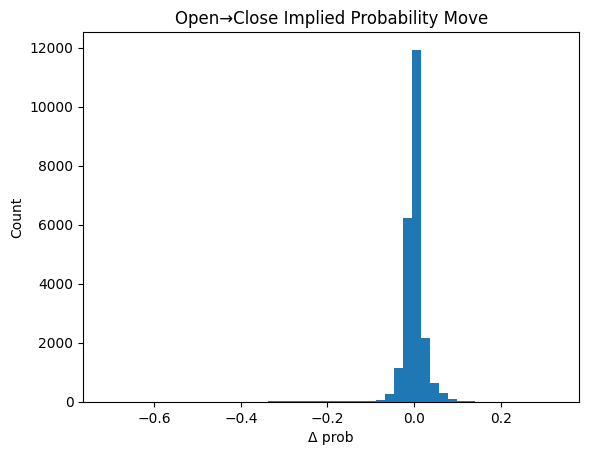

In [12]:
# Histogram of open→close prob moves (all markets)
vals = pd.to_numeric(wide_mv["prob_move_open_close"], errors="coerce").dropna()
plt.figure()
plt.hist(vals, bins=50)
plt.title("Open→Close Implied Probability Move")
plt.xlabel("Δ prob")
plt.ylabel("Count")
plt.show()


In [17]:
wide_mv["prob_move_open_close"].describe()

count    23101.000000
mean        -0.001473
std          0.037001
min         -0.711844
25%         -0.008333
50%          0.000000
75%          0.007843
max          0.329060
Name: prob_move_open_close, dtype: float64

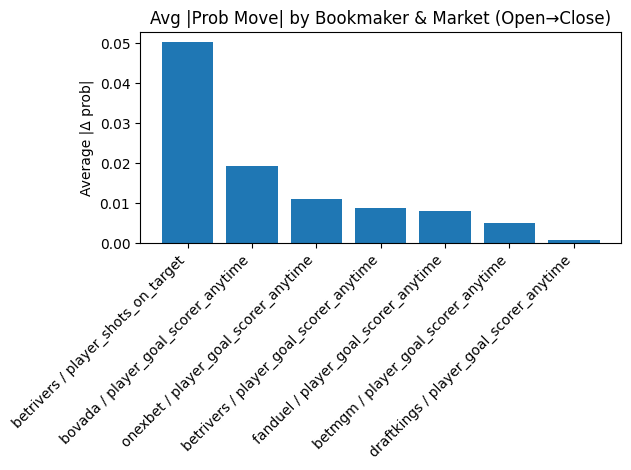

In [13]:
# Top books by avg |prob move| (bar plot)
top_books = summarize_by_bookmaker(wide_mv).head(10)
plt.figure()
plt.bar(top_books["bookmaker"].astype(str) + " / " + top_books["market"].astype(str),
        top_books["avg_abs_prob_move_open_close"])
plt.xticks(rotation=45, ha="right")
plt.title("Avg |Prob Move| by Bookmaker & Market (Open→Close)")
plt.ylabel("Average |Δ prob|")
plt.tight_layout()
plt.show()
